## Objective

The original experiment tested simulation counts up to $1{,}000{,}000$.  
A target 95% confidence-interval half-width of $\$0.01$ was not reached, so the observed requirement was returned as `None`.

That result was valid: it meant the required count lay outside the tested range.

This notebook performs a **targeted follow-up experiment** around the pilot estimates:

| Scenario | Pilot estimate |
|---|---:|
| OTM | approximately 2.95 million |
| ATM | approximately 8.38 million |
| ITM | approximately 14.17 million |

The experiment answers:

1. At what tested simulation count does each scenario first achieve a mean 95% confidence-interval half-width of at most $\$0.01$?
2. Are the pilot estimates consistent with the observed results?
3. Does confidence-interval coverage remain reasonable near the required simulation counts?

Precision and coverage are evaluated separately:

- **Precision requirement:** mean confidence-interval half-width $\leq \$0.01$.
- **Coverage diagnostic:** proportion of intervals containing the Black–Scholes price.

Coverage is not used to define the required simulation count because empirical coverage is noisy and non-monotonic when measured using a finite number of repetitions.

## 1. Imports

In [1]:
from __future__ import annotations

import io
from contextlib import redirect_stdout

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import norm

from derivative_pricing.models.market import MarketData
from derivative_pricing.models.options import EuropeanOption, OptionType
from derivative_pricing.utils.monte_carlo_utils import (
    estimate_required_simulations,
    run_variance_experiment,
    summarise_variance_experiment,
)

## 2. Market and option scenarios

All three options use the same market assumptions. Only the strike changes.

- ITM call: \(K=80\)
- ATM call: \(K=100\)
- OTM call: \(K=120\)

Using the same spot, maturity, interest rate, and volatility isolates the effect of moneyness.

In [3]:
market = MarketData(
    spot=100.0,
    risk_free_rate=0.05,
    volatility=0.20,
)

scenarios = {
    "ITM": EuropeanOption(
        strike=80.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
    "ATM": EuropeanOption(
        strike=100.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
    "OTM": EuropeanOption(
        strike=120.0,
        maturity=1.0,
        type=OptionType.CALL,
    ),
}

confidence_level = 0.95
target_half_width = 0.01

## 3. Re-estimate the required counts from pilot simulations

A pilot simulation estimates the standard deviation of the discounted payoff, $s_X$.

For a target confidence-interval half-width $h$,

$
h=z_{1-\alpha/2}\frac{s_X}{\sqrt N}.
$

Rearranging gives

$
N\geq
\left(
\frac{z_{1-\alpha/2}s_X}{h}
\right)^2.
$

The estimate is itself random because $s_X$ is estimated from a finite pilot sample. It identifies the region to test rather than proving the exact required count.

In [4]:
pilot_rows = []

for scenario, option in scenarios.items():
    estimate = estimate_required_simulations(
        option=option,
        market=market,
        target_half_width=target_half_width,
        confidence_level=confidence_level,
        pilot_simulations=100_000,
        seed=42,
    )
    estimate["scenario"] = scenario
    pilot_rows.append(estimate)

pilot_estimates = (
    pd.DataFrame(pilot_rows)
    .loc[
        :,
        [
            "scenario",
            "pilot_simulations",
            "pilot_price",
            "estimated_discounted_payoff_sd",
            "target_half_width",
            "required_simulations",
        ],
    ]
    .sort_values("scenario")
    .reset_index(drop=True)
)

display(pilot_estimates)

,scenario,pilot_simulations,pilot_price,estimated_discounted_payoff_sd,target_half_width,required_simulations
0,ATM,100000,10.420541,14.789942,0.01,8402899
1,ITM,100000,24.534804,19.226204,0.01,14199835
2,OTM,100000,3.266863,8.753158,0.01,2943241


## 4. Targeted simulation grid

Rather than repeating the complete original grid, this notebook tests counts immediately below, near, and above each pilot estimate.

The default uses **10 repetitions per count**. This is suitable for locating the precision threshold while keeping execution time manageable.

For final coverage validation, increase repetitions only at the first passing count.

In [5]:
targeted_counts = {
    "OTM": [
        2_500_000,
        3_000_000,
        3_500_000,
    ],
    "ATM": [
        7_000_000,
        8_500_000,
        10_000_000,
    ],
    "ITM": [
        12_000_000,
        14_500_000,
        17_000_000,
    ],
}

precision_repetitions = 10
base_seed = 10_000

targeted_counts

{'OTM': [2500000, 3000000, 3500000],
 'ATM': [7000000, 8500000, 10000000],
 'ITM': [12000000, 14500000, 17000000]}

## 5. Run the targeted precision experiment

Each option scenario is run only at the counts relevant to its estimated threshold.

The experiment remains reproducible because every run uses a deterministic seed. Verbose output is captured rather than printed into the notebook.

In [ ]:
frames = []

for scenario, option in scenarios.items():
    print(
        f"Running {scenario}: "
        f"{len(targeted_counts[scenario])} counts x "
        f"{precision_repetitions} repetitions"
    )

    captured_output = io.StringIO()

    with redirect_stdout(captured_output):
        scenario_results = run_variance_experiment(
            scenario=scenario,
            option=option,
            market=market,
            simulation_counts=targeted_counts[scenario],
            repetitions=precision_repetitions,
            confidence_level=confidence_level,
            base_seed=base_seed,
        )

    frames.append(scenario_results)

targeted_results = pd.concat(
    frames,
    ignore_index=True,
)

print(f"Completed {len(targeted_results):,} pricing runs.")

Running ITM: 3 counts × 10 repetitions
Running ATM: 3 counts × 10 repetitions
Running OTM: 3 counts × 10 repetitions
Completed 90 pricing runs.


## 6. Summarise the repeated estimates

For each scenario and simulation count, the summary reports:

- mean Monte Carlo price;
- empirical variance across repetitions;
- mean estimated standard error;
- mean confidence-interval half-width;
- RMSE relative to Black–Scholes;
- empirical confidence-interval coverage;
- mean runtime.

The primary precision metric is `mean_ci_half_width`.

In [7]:
targeted_summary = summarise_variance_experiment(targeted_results)

summary_columns = [
    "scenario",
    "simulations",
    "black_scholes_price",
    "mean_monte_carlo_price",
    "bias",
    "empirical_variance",
    "mean_standard_error",
    "mean_ci_half_width",
    "rmse",
    "confidence_interval_coverage",
    "mean_runtime_ms",
]

display(
    targeted_summary[summary_columns]
    .sort_values(["scenario", "simulations"])
    .reset_index(drop=True)
)

,scenario,simulations,black_scholes_price,mean_monte_carlo_price,bias,empirical_variance,mean_standard_error,mean_ci_half_width,rmse,confidence_interval_coverage,mean_runtime_ms
0,ATM,7000000,10.450584,10.449671,-0.000912,0.000025,0.005563,0.010903,0.004874,1.0,122.542717
1,ATM,8500000,10.450584,10.449203,-0.001380,0.000037,0.005048,0.009894,0.005904,0.8,151.020262
2,ATM,10000000,10.450584,10.450837,0.000253,0.000031,0.004655,0.009124,0.005255,0.9,168.497171
3,ITM,12000000,24.588835,24.587369,-0.001466,0.000022,0.005531,0.010841,0.004699,1.0,220.942258
4,ITM,14500000,24.588835,24.589512,0.000676,0.000035,0.005032,0.009862,0.005638,0.9,246.198984
5,ITM,17000000,24.588835,24.590015,0.001179,0.000037,0.004648,0.009111,0.005871,0.9,293.801488
6,OTM,2500000,3.247477,3.246755,-0.000723,0.000027,0.005483,0.010746,0.005007,0.9,42.462141
7,OTM,3000000,3.247477,3.247790,0.000312,0.000019,0.005008,0.009815,0.004108,1.0,50.893417
8,OTM,3500000,3.247477,3.248110,0.000633,0.000013,0.004636,0.009086,0.003506,1.0,60.063188


## 7. Find the observed precision threshold

The required count is defined as the **first tested simulation count** for which

$$
\text{mean CI half-width}\leq 0.01.
$$

Coverage is deliberately not part of this selection rule.

The observed value is resolution-dependent: it is the first passing count in the tested grid, not necessarily the exact mathematical minimum.

In [8]:
def find_required_simulations_for_precision(
    summary: pd.DataFrame,
    target_half_width: float,
) -> pd.DataFrame:
    """Find the first tested simulation count satisfying the CI-width target."""

    rows: list[dict[str, float | int | str | None]] = []

    for scenario, scenario_df in summary.groupby("scenario"):
        scenario_name = str(scenario)
        scenario_df = scenario_df.sort_values("simulations")

        eligible = scenario_df[scenario_df["mean_ci_half_width"] <= target_half_width]

        if eligible.empty:
            rows.append(
                {
                    "scenario": scenario_name,
                    "target_half_width": target_half_width,
                    "required_simulations": None,
                    "achieved_half_width": None,
                    "coverage_at_required_count": None,
                    "mean_runtime_ms": None,
                }
            )
            continue

        first = eligible.iloc[0]

        rows.append(
            {
                "scenario": scenario_name,
                "target_half_width": target_half_width,
                "required_simulations": int(first["simulations"]),
                "achieved_half_width": float(first["mean_ci_half_width"]),
                "coverage_at_required_count": float(
                    first["confidence_interval_coverage"]
                ),
                "mean_runtime_ms": float(first["mean_runtime_ms"]),
            }
        )

    return pd.DataFrame(rows)


observed_requirements = (
    find_required_simulations_for_precision(
        summary=targeted_summary,
        target_half_width=target_half_width,
    )
    .sort_values("scenario")
    .reset_index(drop=True)
)

display(observed_requirements)

,scenario,target_half_width,required_simulations,achieved_half_width,coverage_at_required_count,mean_runtime_ms
0,ATM,0.01,8500000,0.009894,0.8,151.020262
1,ITM,0.01,14500000,0.009862,0.9,246.198984
2,OTM,0.01,3000000,0.009815,1.0,50.893417


## 8. Compare pilot and observed requirements

The pilot estimate is continuous, while the observed requirement can only be one of the counts included in the validation grid.

The ratio

\[
\frac{N_{\text{observed}}}{N_{\text{pilot}}}
\]

shows how closely the first passing tested count agrees with the pilot prediction.

In [9]:
comparison = (
    pilot_estimates[["scenario", "required_simulations"]]
    .rename(columns={"required_simulations": "pilot_required_simulations"})
    .merge(
        observed_requirements,
        on="scenario",
        how="left",
    )
)

comparison["observed_to_pilot_ratio"] = (
    comparison["required_simulations"] / comparison["pilot_required_simulations"]
)

display(comparison)

,scenario,pilot_required_simulations,target_half_width,required_simulations,achieved_half_width,coverage_at_required_count,mean_runtime_ms,observed_to_pilot_ratio
0,ATM,8402899,0.01,8500000,0.009894,0.8,151.020262,1.011556
1,ITM,14199835,0.01,14500000,0.009862,0.9,246.198984,1.021139
2,OTM,2943241,0.01,3000000,0.009815,1.0,50.893417,1.019285


## 9. Plot confidence-interval half-width against simulation count

The horizontal line represents the one-cent target.

Because half-width follows approximately $N^{-1/2}$, both axes are logarithmic.

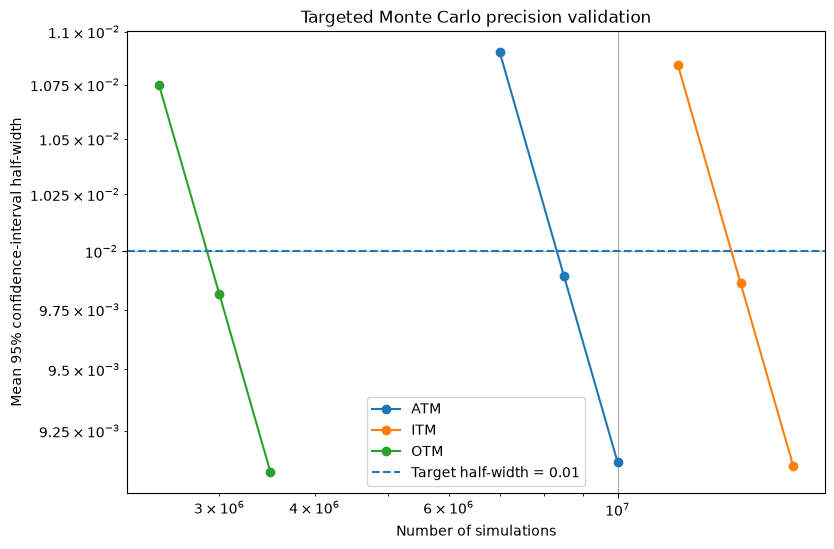

In [10]:
def plot_half_width_validation(
    summary: pd.DataFrame,
    target_half_width: float,
) -> None:
    _, ax = plt.subplots(figsize=(9, 6))

    for scenario, scenario_df in summary.groupby("scenario"):
        data = scenario_df.sort_values("simulations")

        ax.loglog(
            data["simulations"],
            data["mean_ci_half_width"],
            marker="o",
            label=str(scenario),
        )

    ax.axhline(
        target_half_width,
        linestyle="--",
        label=f"Target half-width = {target_half_width:.2f}",
    )

    ax.set_xlabel("Number of simulations")
    ax.set_ylabel("Mean 95% confidence-interval half-width")
    ax.set_title("Targeted Monte Carlo precision validation")
    ax.grid(True)
    ax.legend()

    plt.show()


plot_half_width_validation(
    targeted_summary,
    target_half_width,
)

## 10. Compare observed half-width with theoretical scaling

If the pilot standard-deviation estimate is accurate, predicted half-width at count $N$ is

$$
\widehat h_N
=
z_{1-\alpha/2}
\frac{\widehat\sigma_X}{\sqrt N}.
$$

The observed-to-predicted ratio should be near one.

In [11]:
critical_value = float(norm.ppf(0.5 + confidence_level / 2.0))

predicted_rows = []

for row in targeted_summary.itertuples(index=False):
    scenario_pilot = pilot_estimates.loc[
        pilot_estimates["scenario"] == row.scenario
    ].iloc[0]

    payoff_sd = float(scenario_pilot["estimated_discounted_payoff_sd"])

    predicted_half_width = critical_value * payoff_sd / np.sqrt(float(row.simulations))

    predicted_rows.append(
        {
            "scenario": row.scenario,
            "simulations": int(row.simulations),
            "observed_mean_half_width": float(row.mean_ci_half_width),
            "predicted_half_width": float(predicted_half_width),
            "observed_to_predicted_ratio": float(
                row.mean_ci_half_width / predicted_half_width
            ),
        }
    )

half_width_comparison = pd.DataFrame(predicted_rows)

display(
    half_width_comparison.sort_values(["scenario", "simulations"]).reset_index(
        drop=True
    )
)

,scenario,simulations,observed_mean_half_width,predicted_half_width,observed_to_predicted_ratio
0,ATM,7000000,0.010903,0.010956,0.995142
1,ATM,8500000,0.009894,0.009943,0.995081
2,ATM,10000000,0.009124,0.009167,0.995313
3,ITM,12000000,0.010841,0.010878,0.996616
4,ITM,14500000,0.009862,0.009896,0.996581
5,ITM,17000000,0.009111,0.009139,0.996858
6,OTM,2500000,0.010746,0.010850,0.990424
7,OTM,3000000,0.009815,0.009905,0.990898
8,OTM,3500000,0.009086,0.009170,0.990795


## 11. Coverage diagnostic

Coverage is the proportion of repeated 95% confidence intervals containing the Black–Scholes benchmark.

With only 10 repetitions, this is a coarse diagnostic and should not be used to select the required simulation count.

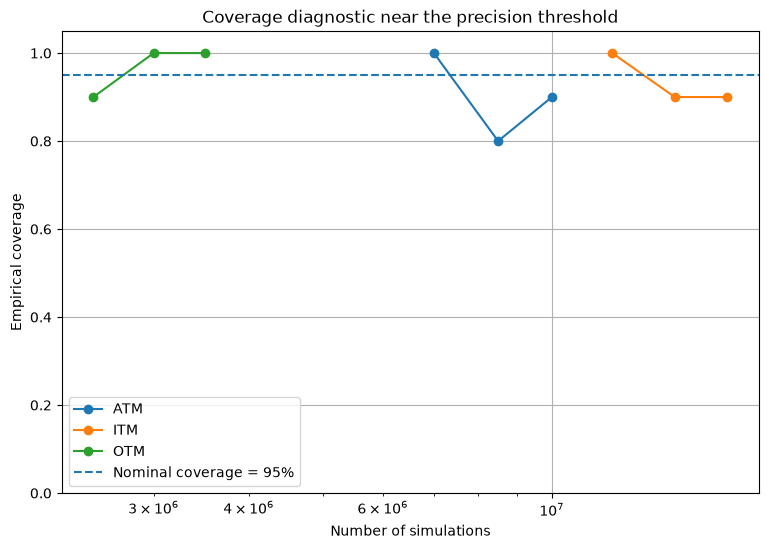

In [12]:
def plot_coverage_diagnostic(
    summary: pd.DataFrame,
    confidence_level: float,
) -> None:
    _, ax = plt.subplots(figsize=(9, 6))

    for scenario, scenario_df in summary.groupby("scenario"):
        data = scenario_df.sort_values("simulations")

        ax.plot(
            data["simulations"],
            data["confidence_interval_coverage"],
            marker="o",
            label=str(scenario),
        )

    ax.axhline(
        confidence_level,
        linestyle="--",
        label=f"Nominal coverage = {confidence_level:.0%}",
    )

    ax.set_xscale("log")
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("Number of simulations")
    ax.set_ylabel("Empirical coverage")
    ax.set_title("Coverage diagnostic near the precision threshold")
    ax.grid(True)
    ax.legend()

    plt.show()


plot_coverage_diagnostic(
    targeted_summary,
    confidence_level,
)

## 12. Runtime analysis

Expected computational cost is approximately linear in \(N\), because each additional path requires one additional draw, terminal-price calculation, payoff calculation, and discounting operation.

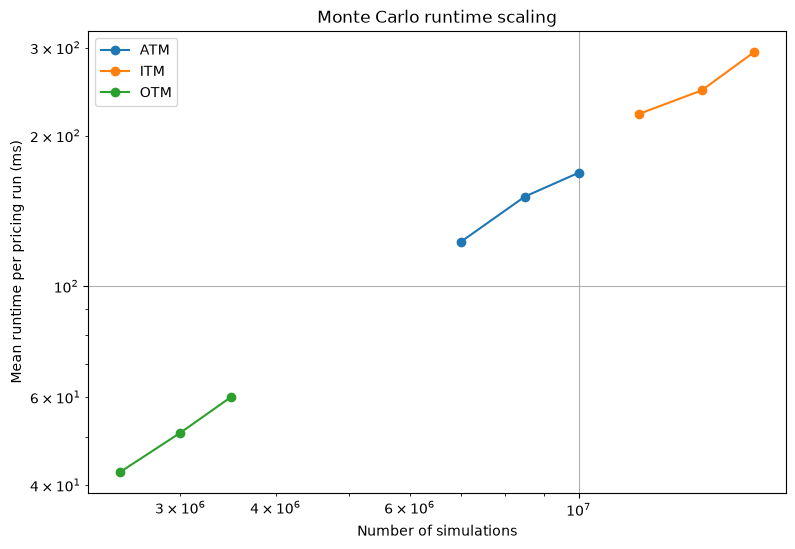

In [13]:
def plot_runtime_scaling(
    summary: pd.DataFrame,
) -> None:
    _, ax = plt.subplots(figsize=(9, 6))

    for scenario, scenario_df in summary.groupby("scenario"):
        data = scenario_df.sort_values("simulations")

        ax.loglog(
            data["simulations"],
            data["mean_runtime_ms"],
            marker="o",
            label=str(scenario),
        )

    ax.set_xlabel("Number of simulations")
    ax.set_ylabel("Mean runtime per pricing run (ms)")
    ax.set_title("Monte Carlo runtime scaling")
    ax.grid(True)
    ax.legend()

    plt.show()


plot_runtime_scaling(targeted_summary)

## 13. Optional dedicated coverage validation

After identifying the first passing precision count, test coverage at that count with more repetitions.

This cell is disabled by default because it may require substantial computation.

Set `RUN_COVERAGE_VALIDATION = True` to execute it.

In [15]:
RUN_COVERAGE_VALIDATION = True
coverage_repetitions = 50

coverage_results = None
coverage_summary = None

if RUN_COVERAGE_VALIDATION:
    coverage_frames = []

    valid_requirements = observed_requirements.dropna(subset=["required_simulations"])

    for row in valid_requirements.itertuples(index=False):
        scenario = str(row.scenario)
        simulations = int(row.required_simulations)

        print(f"Validating {scenario} coverage at {simulations:,} simulations...")

        captured_output = io.StringIO()

        with redirect_stdout(captured_output):
            scenario_results = run_variance_experiment(
                scenario=scenario,
                option=scenarios[scenario],
                market=market,
                simulation_counts=[simulations],
                repetitions=coverage_repetitions,
                confidence_level=confidence_level,
                base_seed=100_000,
            )

        coverage_frames.append(scenario_results)

    coverage_results = pd.concat(
        coverage_frames,
        ignore_index=True,
    )

    coverage_summary = summarise_variance_experiment(coverage_results)

    display(
        coverage_summary[
            [
                "scenario",
                "simulations",
                "mean_ci_half_width",
                "confidence_interval_coverage",
                "mean_runtime_ms",
            ]
        ]
    )
else:
    print("Coverage validation skipped. Set RUN_COVERAGE_VALIDATION = True to run it.")

Validating ATM coverage at 8,500,000 simulations...
Validating ITM coverage at 14,500,000 simulations...
Validating OTM coverage at 3,000,000 simulations...


,scenario,simulations,mean_ci_half_width,confidence_interval_coverage,mean_runtime_ms
0,ATM,8500000,0.009895,0.96,151.210297
1,ITM,14500000,0.009863,0.96,253.409200
2,OTM,3000000,0.009810,0.96,52.327606


## 14. Optional automatic extension

If a scenario still returns `None`, its grid did not reach the required precision.

The suggested next count is estimated from

$$
N_{\text{next}}
=
N_{\text{last}}
\left(
\frac{h_{\text{last}}}{h_{\text{target}}}
\right)^2,
$$

with a 10% safety margin.

In [16]:
extension_rows = []

for scenario, scenario_df in targeted_summary.groupby("scenario"):
    scenario_name = str(scenario)
    data = scenario_df.sort_values("simulations")
    last = data.iloc[-1]

    if float(last["mean_ci_half_width"]) <= target_half_width:
        continue

    suggested_count = int(
        np.ceil(
            float(last["simulations"])
            * (float(last["mean_ci_half_width"]) / target_half_width) ** 2
            * 1.10
        )
    )

    extension_rows.append(
        {
            "scenario": scenario_name,
            "last_tested_simulations": int(last["simulations"]),
            "last_mean_half_width": float(last["mean_ci_half_width"]),
            "suggested_next_simulations": suggested_count,
        }
    )

extension_suggestions = pd.DataFrame(extension_rows)

if extension_suggestions.empty:
    print("All scenarios reached the precision target.")
else:
    display(extension_suggestions)

All scenarios reached the precision target.


## 15. Generate report-ready conclusions

The next cell creates draft conclusions from the observed results.

Review the wording before copying it into the final report, particularly when only a small number of repetitions was used.

In [17]:
for row in comparison.itertuples(index=False):
    scenario = str(row.scenario)
    pilot_count = int(row.pilot_required_simulations)

    if pd.isna(row.required_simulations):
        scenario_summary = targeted_summary[
            targeted_summary["scenario"] == scenario
        ].sort_values("simulations")

        last = scenario_summary.iloc[-1]

        print(
            f"{scenario}: The pilot experiment estimated that "
            f"{pilot_count:,} simulations would be required for a "
            f"95% confidence-interval half-width of $0.01. "
            f"The largest targeted count of "
            f"{int(last['simulations']):,} simulations produced a mean "
            f"half-width of ${float(last['mean_ci_half_width']):.5f}, "
            f"so the target was not reached within the tested range."
        )
        continue

    observed_count = int(row.required_simulations)
    achieved_half_width = float(row.achieved_half_width)

    print(
        f"{scenario}: The pilot experiment estimated that "
        f"{pilot_count:,} simulations would be required for a "
        f"95% confidence-interval half-width of $0.01. "
        f"The first tested count satisfying the target was "
        f"{observed_count:,} simulations, with a mean half-width of "
        f"${achieved_half_width:.5f}."
    )

ATM: The pilot experiment estimated that 8,402,899 simulations would be required for a 95% confidence-interval half-width of $0.01. The first tested count satisfying the target was 8,500,000 simulations, with a mean half-width of $0.00989.
ITM: The pilot experiment estimated that 14,199,835 simulations would be required for a 95% confidence-interval half-width of $0.01. The first tested count satisfying the target was 14,500,000 simulations, with a mean half-width of $0.00986.
OTM: The pilot experiment estimated that 2,943,241 simulations would be required for a 95% confidence-interval half-width of $0.01. The first tested count satisfying the target was 3,000,000 simulations, with a mean half-width of $0.00981.
